## Importing Libraries

In [31]:
import os
import pickle
import pandas as pd
import numpy as np
import random
import string
import re
import numpy as np
from nltk.translate.bleu_score import sentence_bleu
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import TextVectorization

import warnings
warnings.filterwarnings("ignore")

In [32]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Defining Parameters

In [33]:
batch_size = 64
embed_dim = 128
num_heads = 8
latent_dim = 2048
vocab_size = 20000
sequence_length = 20
dropout = 0.2

## Defining Functions

In [ ]:
def preprocess_text(df):
    df["english_sent"] = df["english_sent"].str.lower()
    df["hindi_sent"] = df["hindi_sent"].str.lower()

    df["english_sent"] = df["english_sent"].str.replace(r"http\S+", "", regex=True)
    df["hindi_sent"] = df["hindi_sent"].str.replace(r"http\S+", "", regex=True)

    df["english_sent"] = df["english_sent"].str.replace(r"[0-9]", "", regex=True)
    df["hindi_sent"] = df["hindi_sent"].str.replace(r"[0-9]", "", regex=True)

    df["hindi_sent"] = df["hindi_sent"].str.replace(r"[a-zA-Z]", "", regex=True)

    df["english_sent"] = df["english_sent"].str.replace(r"[^\w\s]", "", regex=True)
    df["hindi_sent"] = df["hindi_sent"].str.replace(r"[^\w\s]", "", regex=True)

    df["english_sent"] = df["english_sent"].str.strip().str.replace(r"\s+", " ", regex=True)
    df["hindi_sent"] = df["hindi_sent"].str.strip().str.replace(r"\s+", " ", regex=True)

    df["hindi_sent"] = "[start] " + df["hindi_sent"] + " [end]"

    return df

In [1]:
def decode_sequence(input_sentence):
    hindi_vocab = hindi_vectorization.get_vocabulary()
    hindi_index_lookup = dict(zip(range(len(hindi_vocab)), hindi_vocab))
    max_decoded_sentence_length = 20

    tokenized_input_sentence = eng_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = hindi_vectorization([decoded_sentence])[:, :-1]
        predictions = transformer([tokenized_input_sentence, tokenized_target_sentence])

        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = hindi_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token

        if sampled_token == "[end]":
            break

    return decoded_sentence[8:-5]

In [36]:
# For creating Dataset
def format_dataset(eng, hin):
    eng = eng_vectorization(eng)
    hindi = hindi_vectorization(hin)
    return ({"encoder_inputs" : eng, "decoder_inputs" : hindi[:, :-1],}, hindi[:, 1:])

def make_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((df["english_sent"].values, df["hindi_sent"].values))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    return dataset.shuffle(2048).prefetch(16).cache()


## Reading Data & Preprocessing Text

In [37]:
from google.colab import files
import io

print('Please upload your CSV dataset file (e.g. Hindi_English_Truncated_Corpus.csv)')
uploaded = files.upload()

# Read whichever file was uploaded
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.drop(["source"], axis=1, inplace=True)
df.dropna(axis=0, inplace=True)
df.rename(columns={"english_sentence": "english_sent", "hindi_sentence": "hindi_sent"}, inplace=True)
df.head()

Please upload your CSV dataset file (e.g. Hindi_English_Truncated_Corpus.csv)


Saving Hindi_English_Truncated_Corpus.csv to Hindi_English_Truncated_Corpus (1).csv


,english_sent,hindi_sent
0,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


In [38]:
preprocess_text(df)

df.drop(df[df["english_sent"] == " "].index, inplace = True)
df.drop(df[df["hindi_sent"] == "[start]  [end]"].index, inplace = True)

In [39]:
df["eng_sent_length"] = df["english_sent"].apply(lambda x : len(x.split(' ')))
df["hindi_sent_length"] = df["hindi_sent"].apply(lambda x : len(x.split(' ')))

In [40]:
df = df[df["eng_sent_length"] <= 20]
df = df[df["hindi_sent_length"] <= 20]

df = df.sample(n = 85000, random_state = 2048)
df = df.reset_index(drop = True)

train = df.iloc[:80000]
val = df.iloc[80000:84500]
test = df.iloc[84500:]

## Tokenizing Sentences


In [41]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")


def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")

eng_vectorization = TextVectorization(
    max_tokens = vocab_size, output_mode = "int", output_sequence_length = sequence_length
    )

hindi_vectorization = TextVectorization(
    max_tokens = vocab_size, output_mode = "int", output_sequence_length = sequence_length + 1, standardize=custom_standardization
)

eng_vectorization.adapt(df["english_sent"].values)
hindi_vectorization.adapt(df["hindi_sent"].values)

In [42]:
pickle.dump({'config': eng_vectorization.get_config(),
             'weights': eng_vectorization.get_weights()}
            , open("eng_vectorizer.pkl", "wb"))

pickle.dump({'config': hindi_vectorization.get_config(),
             'weights': hindi_vectorization.get_weights()}
            , open("hindi_vectorizer.pkl", "wb"))

## Creating Dataset


In [43]:
train_ds = make_dataset(train)
val_ds = make_dataset(val)

## Creating Model

In [44]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_len, vocab_size, embed_dim, **kwargs):
        super(PositionalEmbedding, self).__init__(**kwargs)
        self.sequence_len = sequence_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_embedding = layers.Embedding(
            input_dim = vocab_size, output_dim = embed_dim
        )
        self.position_embedding = layers.Embedding(
            input_dim = sequence_len, output_dim = embed_dim
        )

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start = 0, limit = length, delta = 1)
        embedded_tokens = self.token_embedding(inputs)
        embedded_positions = self.position_embedding(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return keras.ops.not_equal(inputs, 0)

In [45]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, dropout, **kwargs):
        super().__init__(**kwargs)

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )

        self.layer_norm1 = layers.LayerNormalization()
        self.layer_norm2 = layers.LayerNormalization()

        self.layer_ffn = keras.Sequential([
            layers.Dense(latent_dim, activation="relu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])

        self.supports_masking = True

    def call(self, inputs, mask=None):
        # ✅ Safe mask handling
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.bool)
        else:
            padding_mask = None

        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=padding_mask
        )

        ffn_input = self.layer_norm1(inputs + attention_output)
        ffn_output = self.layer_ffn(ffn_input)

        return self.layer_norm2(ffn_input + ffn_output)

In [46]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, dropout, **kwargs):
        super().__init__(**kwargs)

        self.attention1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.attention2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )

        self.dense_proj = keras.Sequential([
            layers.Dense(latent_dim, activation="relu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])

        self.layer_norm1 = layers.LayerNormalization()
        self.layer_norm2 = layers.LayerNormalization()
        self.layer_norm3 = layers.LayerNormalization()

        self.supports_masking = True

    def call(self, inputs, encoder_outputs, mask=None):
        # ✅ 1. Create causal mask
        causal_mask = self.get_causal_attention_mask(inputs)

        # ✅ 2. Handle padding mask safely
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.bool)
            seq_len = tf.shape(inputs)[1]

            padding_mask = tf.tile(padding_mask, [1, seq_len, 1])
            combined_mask = tf.logical_and(padding_mask, causal_mask)
        else:
            combined_mask = causal_mask

        # ✅ 3. Self-attention (masked!)
        attention_output1 = self.attention1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask
        )
        out1 = self.layer_norm1(inputs + attention_output1)

        # ✅ 4. Cross-attention (only padding mask)
        if mask is not None:
            enc_padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.bool)
        else:
            enc_padding_mask = None

        attention_output2 = self.attention2(
            query=out1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=enc_padding_mask
        )
        out2 = self.layer_norm2(out1 + attention_output2)

        # ✅ 5. Feed Forward
        ffn_output = self.dense_proj(out2)
        return self.layer_norm3(out2 + ffn_output)

    def get_causal_attention_mask(self, inputs):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]

        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)

        mask = tf.cast(i >= j, dtype=tf.bool)
        mask = tf.reshape(mask, (1, seq_len, seq_len))

        return tf.tile(mask, [batch_size, 1, 1])

In [47]:
encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads, dropout,name="encoder_1")(x)
encoder = keras.Model(encoder_inputs, encoder_outputs)

decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="decoder_state_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads, dropout,name="decoder_1")(x, encoded_seq_inputs)
x = layers.Dropout(0.4)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)
decoder = keras.Model([decoder_inputs, encoded_seq_inputs], decoder_outputs)

decoder_outputs = decoder([decoder_inputs, encoder_outputs])
transformer = keras.Model(
    [encoder_inputs, decoder_inputs], decoder_outputs, name="transformer"
)

## Training Model

In [48]:
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = transformer.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.2704 - loss: 5.2648 - val_accuracy: 0.3271 - val_loss: 4.5227 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.3566 - loss: 4.2212 - val_accuracy: 0.3877 - val_loss: 3.9162 - learning_rate: 0.0010
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.4173 - loss: 3.5774 - val_accuracy: 0.4241 - val_loss: 3.5549 - learning_rate: 0.0010
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.4671 - loss: 3.1112 - val_accuracy: 0.4528 - val_loss: 3.3624 - learning_rate: 0.0010
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.5068 - loss: 2.7718 - val_accuracy: 0.4653 - val_loss: 3.2837 - learning_rate: 0.0010
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.5379 - loss: 2.5185 - val_accuracy: 0.4741 - val_loss: 3.2751 - learning_rate: 0.0010
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accura

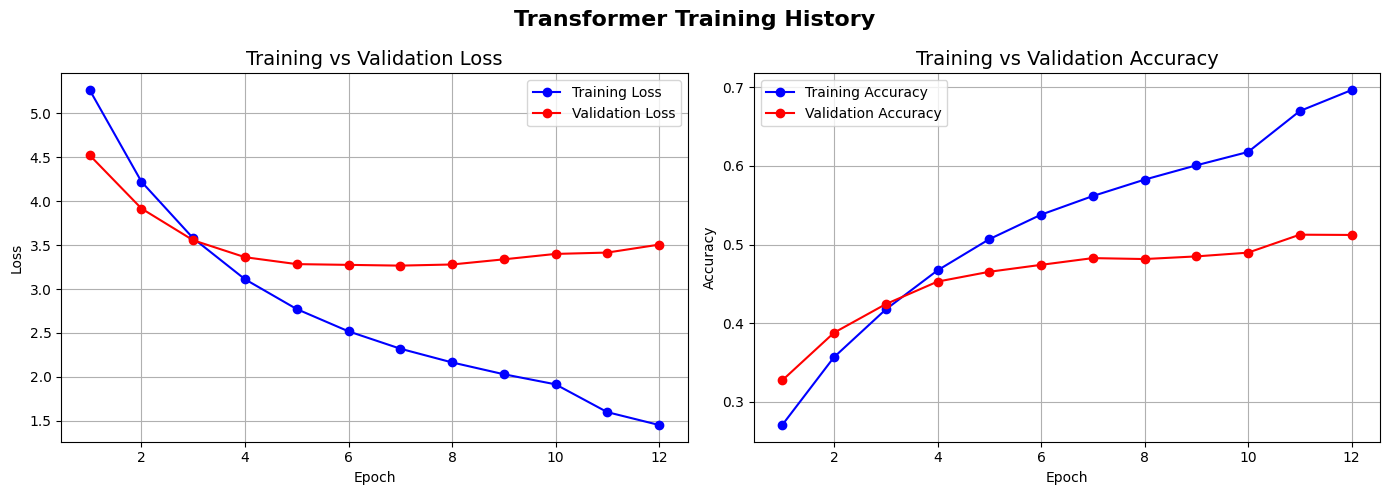

Plot saved as training_plot.png


In [49]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history.history['loss'], 'b-o', label='Training Loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history.history['accuracy'], 'b-o', label='Training Accuracy')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transformer Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_plot.png')

In [51]:
transformer.save_weights("eng-hin.weights.h5")

## Testing Model & Calculating BLEU Score

In [55]:
eng = "how are you"
print("English Sentence : ",eng)
print("Translated Sentence : ",decode_sequence(eng))

eng = "What is your name?"
print("English Sentence : ",eng)
print("Translated Sentence : ",decode_sequence(eng))
eng = "Who are you?"
print("English Sentence : ",eng)
print("Translated Sentence : ",decode_sequence(eng))

English Sentence :  how are you
Translated Sentence :  आप कैसे हैं 
English Sentence :  What is your name?
Translated Sentence :  आप का क्या है 
English Sentence :  Who are you?
Translated Sentence :  जो आप हैं 


In [53]:
eng = test["english_sent"].values
original = test["hindi_sent"].values

translated = [decode_sequence(sent) for sent in eng]
bleu = 0

for i in range(test.shape[0]):
    bleu += sentence_bleu([original[i].split()], translated[i].split(), weights = (0.5, 0.5))

print("BLEU score is : ", bleu / test.shape[0])

BLEU score is :  0.1158370692717976
